# Source Finding - SCAR dataset
1️⃣ Can we find the closed using RAG system (embedding) ?

2️⃣ Is it possible to improve the output of tournment style using filteration from the RAG? Depends on how much of the time the correct is in the RAG system 

3️⃣ Maybe we need to create a classifyer head ? 


### `Extraction of data`

In [17]:
import pandas as pd
df_scar = pd.read_csv('../../data/SCAR_cleaned_manually.csv')

In [18]:
df_scar.head()

,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130


In [19]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from tqdm.notebook import tqdm
import json
import time

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Loaded SCAR dataset: {len(df_scar)} analogies")
print(f"Unique targets (system_a): {df_scar['system_a'].nunique()}")
print(f"Unique sources (system_b): {df_scar['system_b'].nunique()}")


Loaded SCAR dataset: 400 analogies
Unique targets (system_a): 321
Unique sources (system_b): 333


## Configuration

Set up API keys and test parameters


In [20]:
# Configuration
import os
from dotenv import load_dotenv

# Load environment variables (if using .env file)
load_dotenv('../../.env')

# Test configuration
TEST_MODE = True  # Set to False to run on full dataset
TEST_SAMPLE_SIZE = 10  # Number of examples to test
TOP_K = 20  # Number of top results to retrieve

# Tournament configuration
TOURNAMENT_BATCH_SIZE = 150 

# Models to test (start with 2)
TEST_MODELS = [
    "gpt-4.1-mini",  # OpenAI
    "meta-llama-3-1-70b-instruct",  # DeepInfra
]

# Results directory
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Test Mode: {TEST_MODE}")
if TEST_MODE:
    print(f"Sample Size: {TEST_SAMPLE_SIZE}")
print(f"Top-K: {TOP_K}")
print(f"Tournament Batch Size: {TOURNAMENT_BATCH_SIZE}")
print(f"Models: {TEST_MODELS}")


Test Mode: True
Sample Size: 10
Top-K: 20
Tournament Batch Size: 150
Models: ['gpt-4.1-mini', 'meta-llama-3-1-70b-instruct']


## Method 1: RAG-Based Source Finding

`Embedding the words only`

Using OpenAI embeddings and cosine similarity to find analogous sources,
here there is no training whatsoever done. It is just seeing if the embedding space somehow correlate?


In [21]:
# Multi-Mode RAG Evaluation
# Test all embedding modes and store separate results

from rag_source_finder import RAGSourceFinder

# Define all embedding modes to test
EMBEDDING_MODES = ["name_only", "name_background", "name_properties", "name_properties_background"]
#EMBEDDING_MODES = ["name_only"]
print("Testing RAG Source Finder with Multiple Embedding Modes")
print("=" * 60)

# Store results for all modes
all_mode_results = {}
mode_performance = {}

for mode in EMBEDDING_MODES:
    print(f"\n{'='*20} Testing Mode: {mode} {'='*20}")
    
    # Initialize RAG finder with specific mode
    print(f"Initializing RAG Source Finder with mode: {mode}")
    rag_finder = RAGSourceFinder(embedding_mode=mode)
    
    # Load corpus
    print("Loading corpus...")
    rag_finder.load_corpus_from_csv('../../data/SCAR_cleaned_manually.csv')
    
    # Embed corpus (this will take a moment)
    print("Embedding corpus (this may take a minute)...")
    rag_finder.embed_corpus()
    
    print("RAG finder ready!")
    
    # Run RAG evaluation
    print("Running RAG evaluation...")
    rag_results = rag_finder.evaluate_on_dataset(
        '../../data/SCAR_cleaned_manually.csv',
        top_k=TOP_K
    )
    
    print(f"Completed! Evaluated {len(rag_results)} examples")
    
    # Store results
    all_mode_results[mode] = rag_results
    
    # Calculate performance metrics
    total_examples = len(rag_results)
    found_in_top_k = len(rag_results[rag_results['gold_rank'] > 0])
    found_at_rank_1 = len(rag_results[rag_results['gold_rank'] == 1])
    
    mode_performance[mode] = {
        'total_examples': total_examples,
        'found_in_top_k': found_in_top_k,
        'found_at_rank_1': found_at_rank_1,
        'top_k_accuracy': found_in_top_k / total_examples if total_examples > 0 else 0,
        'rank_1_accuracy': found_at_rank_1 / total_examples if total_examples > 0 else 0,
        'avg_gold_rank': rag_results[rag_results['gold_rank'] > 0]['gold_rank'].mean() if found_in_top_k > 0 else None
    }
    
    # Display sample results for this mode
    print(f"\nSample Results for Mode '{mode}':")
    print("-" * 50)
    for idx, row in rag_results.head(3).iterrows():
        print(f"Target: {row['target']}")
        print(f"Gold Source: {row['gold_source']}")
        print(f"Predicted (Rank 1): {row['predicted_rank_1']}")
        print(f"Gold Rank: {row['gold_rank']}")
        print(f"Top 3 sources: {row['top_k_sources'][:3]}")
        print()
    
    # Save results for this mode
    mode_filename = f"rag_results_{mode}.csv"
    rag_results_path = os.path.join(RESULTS_DIR, mode_filename)
    rag_results.to_csv(rag_results_path, index=False)
    print(f"Saved {mode} results to {rag_results_path}")

print(f"\n{'='*60}")
print("All embedding modes completed!")
print(f"Results saved for {len(all_mode_results)} modes:")
for mode in EMBEDDING_MODES:
    print(f"  - {mode}: {len(all_mode_results[mode])} examples")


Testing RAG Source Finder with Multiple Embedding Modes

==================== Testing Mode: name_only ====================
Initializing RAG Source Finder with mode: name_only


Loading corpus...
Loaded 333 unique sources from corpus (mode: name_only)
Embedding corpus (this may take a minute)...
Generating embeddings for corpus...
Generated 333 embeddings
RAG finder ready!
Running RAG evaluation...
Evaluating on 400 examples...
Processed 10/400 examples
Processed 20/400 examples
Processed 30/400 examples
Processed 40/400 examples
Processed 50/400 examples
Processed 60/400 examples
Processed 70/400 examples
Processed 80/400 examples
Processed 90/400 examples
Processed 100/400 examples
Processed 110/400 examples
Processed 120/400 examples
Processed 130/400 examples
Processed 140/400 examples
Processed 150/400 examples
Processed 160/400 examples
Processed 170/400 examples
Processed 180/400 examples
Processed 190/400 examples
Processed 200/400 examples
Processed 210/400 examples
Processed 220/400 examples
Processed 230/400 examples
Processed 240/400 examples
Processed 250/400 examples
Processed 260/400 examples
Processed 270/400 examples
Processed 280/400 examples

In [22]:
# RAG Visualization and Analysis
from rag_visualization import RAGDataLoader, RankingMetrics, RAGVisualizer, ComprehensiveAnalyzer

# Load all RAG results
loader = RAGDataLoader("results")
data = loader.load_all_results()

# Calculate metrics for all modes
all_metrics = {}
for mode, df in data.items():
    print(f"Calculating metrics for: {mode}")
    all_metrics[mode] = RankingMetrics.calculate_all_metrics(df)

# Create metrics DataFrame for easy comparison
metrics_df = pd.DataFrame(all_metrics).T
print("\nMetrics Summary:")
print(metrics_df[['MRR', 'MAP', 'NDCG@20', 'Hit@1', 'Hit@5', 'Hit@10']].round(4))


Loading RAG results from results
  Loading rag_results_name_background.csv...


  Loading rag_results_name_only.csv...
  Loading rag_results_name_properties.csv...
  Loading rag_results_name_properties_background.csv...
Loaded 4 embedding modes
Calculating metrics for: name_background
Calculating metrics for: name_only
Calculating metrics for: name_properties
Calculating metrics for: name_properties_background

Metrics Summary:
                               MRR     MAP  NDCG@20   Hit@1   Hit@5  Hit@10
name_background             0.1791  0.1791   0.2560  0.0850  0.2950  0.3875
name_only                   0.2337  0.2337   0.3105  0.1325  0.3575  0.4700
name_properties             0.2336  0.2336   0.3105  0.1325  0.3575  0.4675
name_properties_background  0.1793  0.1793   0.2563  0.0850  0.2950  0.3875


In [23]:
# Generate all visualizations
print("Generating visualizations...")

# Initialize visualizer
visualizer = RAGVisualizer("results/visualizations")

# 1. Performance heatmap
visualizer.plot_performance_heatmap(metrics_df)

# 2. Hit@K curves
visualizer.plot_hit_at_k_curves(metrics_df)

# 3. Rank distribution histograms
visualizer.plot_rank_distribution(data)

# 4. MRR/MAP/NDCG comparison
visualizer.plot_metric_comparison(metrics_df)

# 5. Golden answer coverage analysis
visualizer.plot_golden_coverage(data)

# 6. Similarity score distributions
visualizer.plot_score_distribution(data)

# 7. Failure analysis
visualizer.plot_failure_analysis(data)

# 8. Recall@K curves
visualizer.plot_recall_at_k_curves(metrics_df)

print("All visualizations saved to results/visualizations/")


Generating visualizations...
  Saved: results\visualizations\01_performance_heatmap.png
  Saved: results\visualizations\02_hit_at_k_curves.png
  Saved: results\visualizations\03_rank_distribution.png
  Saved: results\visualizations\04_mrr_map_ndcg_comparison.png
  Saved: results\visualizations\05_golden_answer_coverage.png
  Saved: results\visualizations\06_score_distribution.png
  Saved: results\visualizations\07_failure_analysis.png
  Saved: results\visualizations\08_recall_at_k_curves.png
All visualizations saved to results/visualizations/


In [24]:
# Run comprehensive analysis and generate summary report
print("Running comprehensive analysis...")

# Initialize comprehensive analyzer
analyzer = ComprehensiveAnalyzer(
    results_dir="results",
    output_dir="results/visualizations"
)

# Set the data and metrics we already calculated
analyzer.data = data
analyzer.metrics = all_metrics

# Save comprehensive metrics
analyzer.save_comprehensive_metrics()

# Generate summary report
analyzer.generate_summary_report()

print("Comprehensive analysis complete!")
print("Check the following files:")
print("- results/rag_comprehensive_metrics.csv")
print("- results/rag_analysis_summary.txt")
print("- results/visualizations/ (all PNG files)")


Running comprehensive analysis...
  Saved comprehensive metrics to: results\rag_comprehensive_metrics.csv
  Saved summary report to: results\rag_analysis_summary.txt
Comprehensive analysis complete!
Check the following files:
- results/rag_comprehensive_metrics.csv
- results/rag_analysis_summary.txt
- results/visualizations/ (all PNG files)


Performance Comparison Across Embedding Modes

Performance Metrics:
                            total_examples  found_in_top_k  found_at_rank_1  \
name_only                            400.0           230.0             53.0   
name_background                      400.0           210.0             34.0   
name_properties                      400.0           230.0             53.0   
name_properties_background           400.0           210.0             34.0   

                            top_k_accuracy  rank_1_accuracy  avg_gold_rank  
name_only                            0.575           0.1325         5.7130  
name_background                      0.525           0.0850         6.6381  
name_properties                      0.575           0.1325         5.7174  
name_properties_background           0.525           0.0850         6.6286  


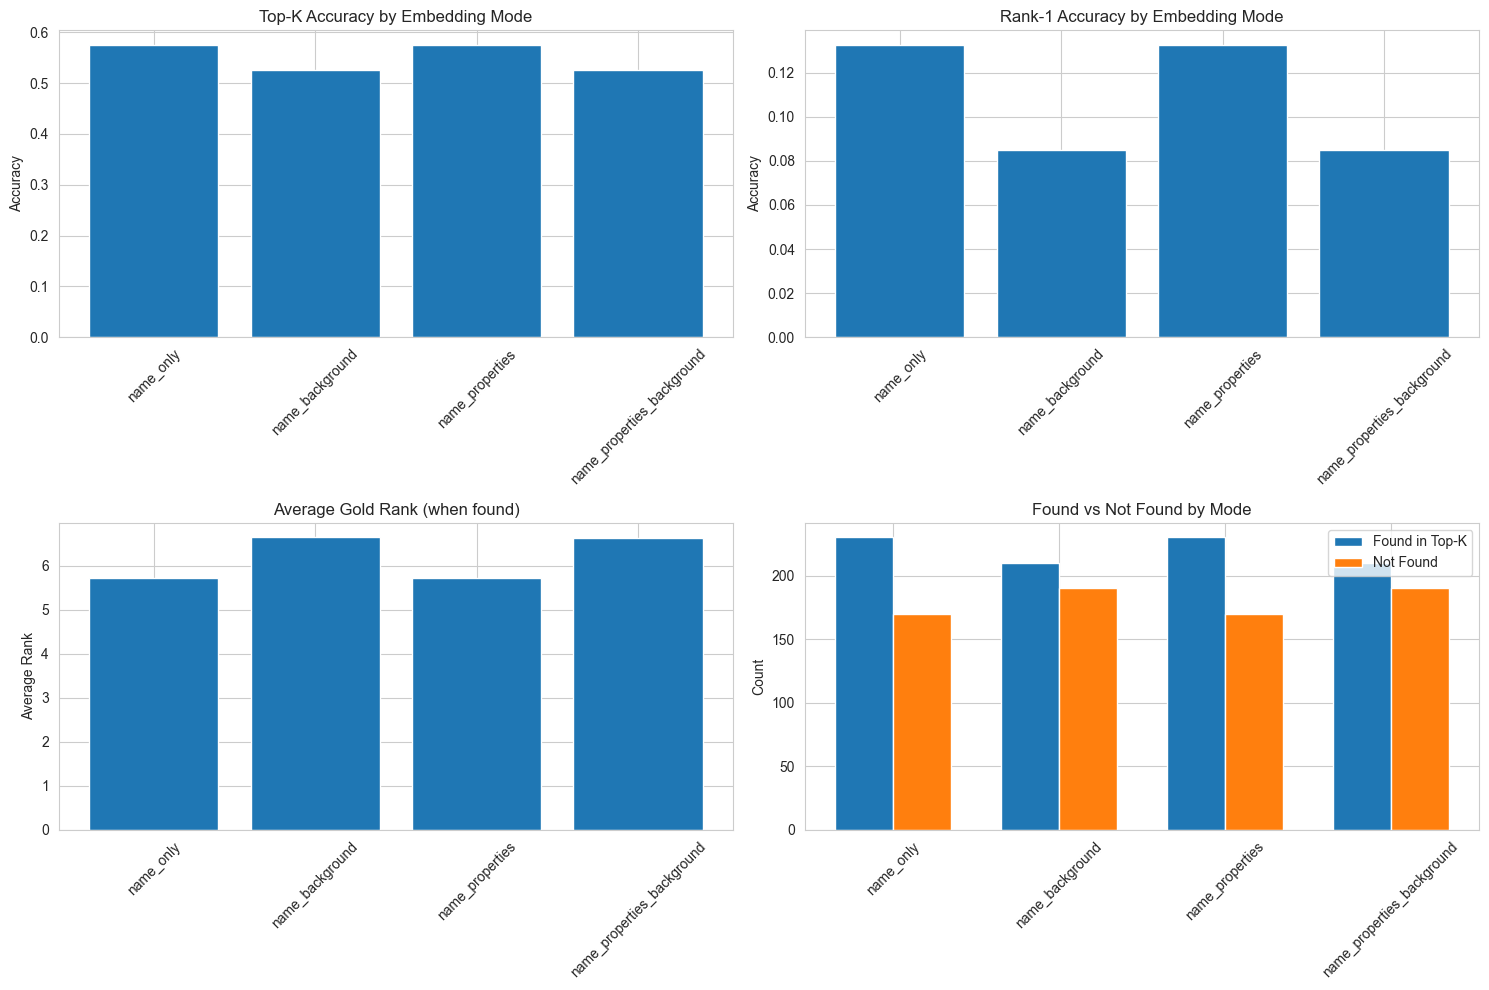


Saved performance comparison to results\rag_performance_comparison.csv

SUMMARY:
Best Top-K Accuracy: name_only (0.5750)
Best Rank-1 Accuracy: name_only (0.1325)
Best Average Rank: name_only (5.71)


In [25]:
# Performance Comparison Across All Modes

print("Performance Comparison Across Embedding Modes")
print("=" * 60)

# Create performance comparison DataFrame
performance_df = pd.DataFrame(mode_performance).T
performance_df = performance_df.round(4)

print("\nPerformance Metrics:")
print(performance_df)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Top-K Accuracy
axes[0, 0].bar(performance_df.index, performance_df['top_k_accuracy'])
axes[0, 0].set_title('Top-K Accuracy by Embedding Mode')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Rank-1 Accuracy
axes[0, 1].bar(performance_df.index, performance_df['rank_1_accuracy'])
axes[0, 1].set_title('Rank-1 Accuracy by Embedding Mode')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Average Gold Rank (for found items)
found_ranks = performance_df['avg_gold_rank'].dropna()
if len(found_ranks) > 0:
    axes[1, 0].bar(found_ranks.index, found_ranks)
    axes[1, 0].set_title('Average Gold Rank (when found)')
    axes[1, 0].set_ylabel('Average Rank')
    axes[1, 0].tick_params(axis='x', rotation=45)
else:
    axes[1, 0].text(0.5, 0.5, 'No data available', ha='center', va='center')
    axes[1, 0].set_title('Average Gold Rank (when found)')

# 4. Found vs Not Found
found_counts = performance_df['found_in_top_k']
not_found_counts = performance_df['total_examples'] - found_counts

x = np.arange(len(performance_df.index))
width = 0.35

axes[1, 1].bar(x - width/2, found_counts, width, label='Found in Top-K')
axes[1, 1].bar(x + width/2, not_found_counts, width, label='Not Found')
axes[1, 1].set_title('Found vs Not Found by Mode')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(performance_df.index, rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Save performance comparison
performance_path = os.path.join(RESULTS_DIR, "rag_performance_comparison.csv")
performance_df.to_csv(performance_path)
print(f"\nSaved performance comparison to {performance_path}")

# Print summary
print(f"\n{'='*60}")
print("SUMMARY:")
print(f"{'='*60}")
best_top_k_mode = performance_df['top_k_accuracy'].idxmax()
best_rank1_mode = performance_df['rank_1_accuracy'].idxmax()

print(f"Best Top-K Accuracy: {best_top_k_mode} ({performance_df.loc[best_top_k_mode, 'top_k_accuracy']:.4f})")
print(f"Best Rank-1 Accuracy: {best_rank1_mode} ({performance_df.loc[best_rank1_mode, 'rank_1_accuracy']:.4f})")

if performance_df['avg_gold_rank'].notna().any():
    best_avg_rank_mode = performance_df['avg_gold_rank'].idxmin()
    print(f"Best Average Rank: {best_avg_rank_mode} ({performance_df.loc[best_avg_rank_mode, 'avg_gold_rank']:.2f})")
